In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:

# --- 1. Load and Preprocess Data ---
try:
    # Load the dataset from the uploaded file
    file_path = 'netflix_customer_churn (1).csv'
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please make sure it's in the same folder as the script.")
    exit()

Dataset loaded successfully.


In [11]:
df.head(5)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [12]:
# Drop irrelevant columns
df = df.drop(columns=['customer_id', 'region'])

In [13]:
# --- Handle Outliers (Capping) ---
# Cap 'avg_watch_time_per_day'
percentile_99_avg = df['avg_watch_time_per_day'].quantile(0.99)
df['avg_watch_time_per_day'] = df['avg_watch_time_per_day'].clip(upper=percentile_99_avg)
# Cap 'watch_hours'
percentile_99_wh = df['watch_hours'].quantile(0.99)
df['watch_hours'] = df['watch_hours'].clip(upper=percentile_99_wh)
print("Outliers handled.")


Outliers handled.


In [14]:
# --- Feature Engineering ---
# Create 'engagement_score'
df['engagement_score'] = df['watch_hours'] / (df['last_login_days'] + 1)

# One-Hot Encode Categorical Features
categorical_features = ['gender', 'subscription_type', 'device', 'payment_method', 'favorite_genre']
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)
print("Data preprocessing and feature engineering complete.")


Data preprocessing and feature engineering complete.


In [15]:
# --- 2. Split Data ---
# Define features (X) and target (y)
X = df_encoded.drop('churned', axis=1)
y = df_encoded['churned']


In [16]:

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# --- 3. Scale Numerical Features ---
# Identify numeric columns to scale
# We scale after splitting to prevent data leakage from the test set
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
print("Numerical features scaled.")

Numerical features scaled.


## Logistic Regression

In [18]:
# --- 4. Train Logistic Regression Model ---
print("\nTraining Logistic Regression model...")
log_reg = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for convergence
log_reg.fit(X_train, y_train)
print("Model training complete.")


Training Logistic Regression model...
Model training complete.


In [19]:
# --- 5. Evaluate the Model ---
# Make predictions on the test set
y_pred = log_reg.predict(X_test)

# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

# Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 0.8970

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       498
           1       0.88      0.92      0.90       502

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000




Confusion Matrix:
[[436  62]
 [ 41 461]]


Text(0.5, 36.72222222222221, 'Predicted')

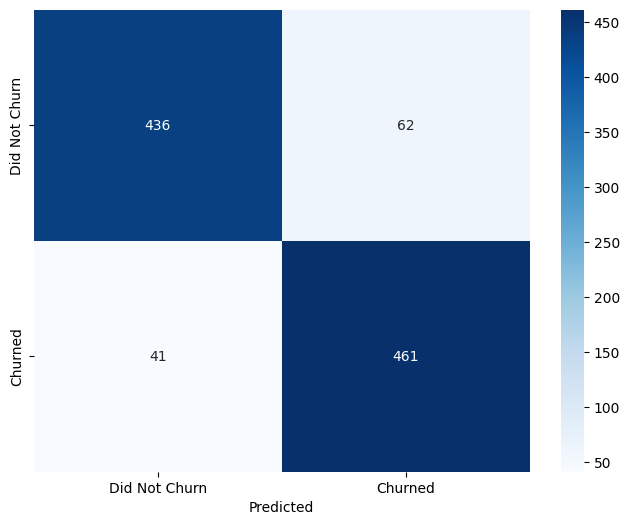

In [17]:
# Generate and display the confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot the confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Did Not Churn', 'Churned'], yticklabels=['Did Not Churn', 'Churned'])
plt.xlabel('Predicted')

## DECISION TREE

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [20]:
# --- 4. Train Decision Tree Model ---
print("\nTraining Decision Tree model...")
# We can add max_depth to prevent overfitting
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_classifier.fit(X_train, y_train)
print("Model training complete.")



Training Decision Tree model...
Model training complete.



Model Accuracy: 0.9130

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       498
           1       0.93      0.90      0.91       502

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000


Confusion Matrix:
[[462  36]
 [ 51 451]]

Confusion matrix plot saved as 'confusion_matrix_decision_tree.png'


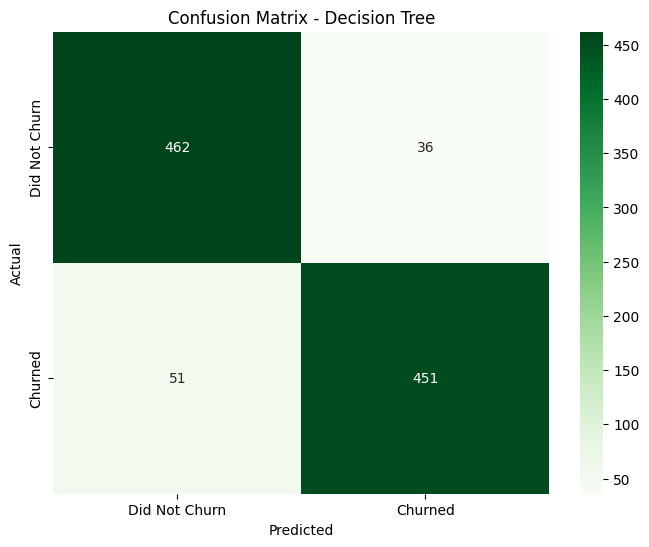

In [23]:
# --- 5. Evaluate the Model ---
y_pred = dt_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Did Not Churn', 'Churned'], yticklabels=['Did Not Churn', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.savefig('confusion_matrix_decision_tree.png')
print("\nConfusion matrix plot saved as 'confusion_matrix_decision_tree.png'")
plt.show()



Visualizing the Decision Tree...
Decision Tree plot saved as 'decision_tree.png'


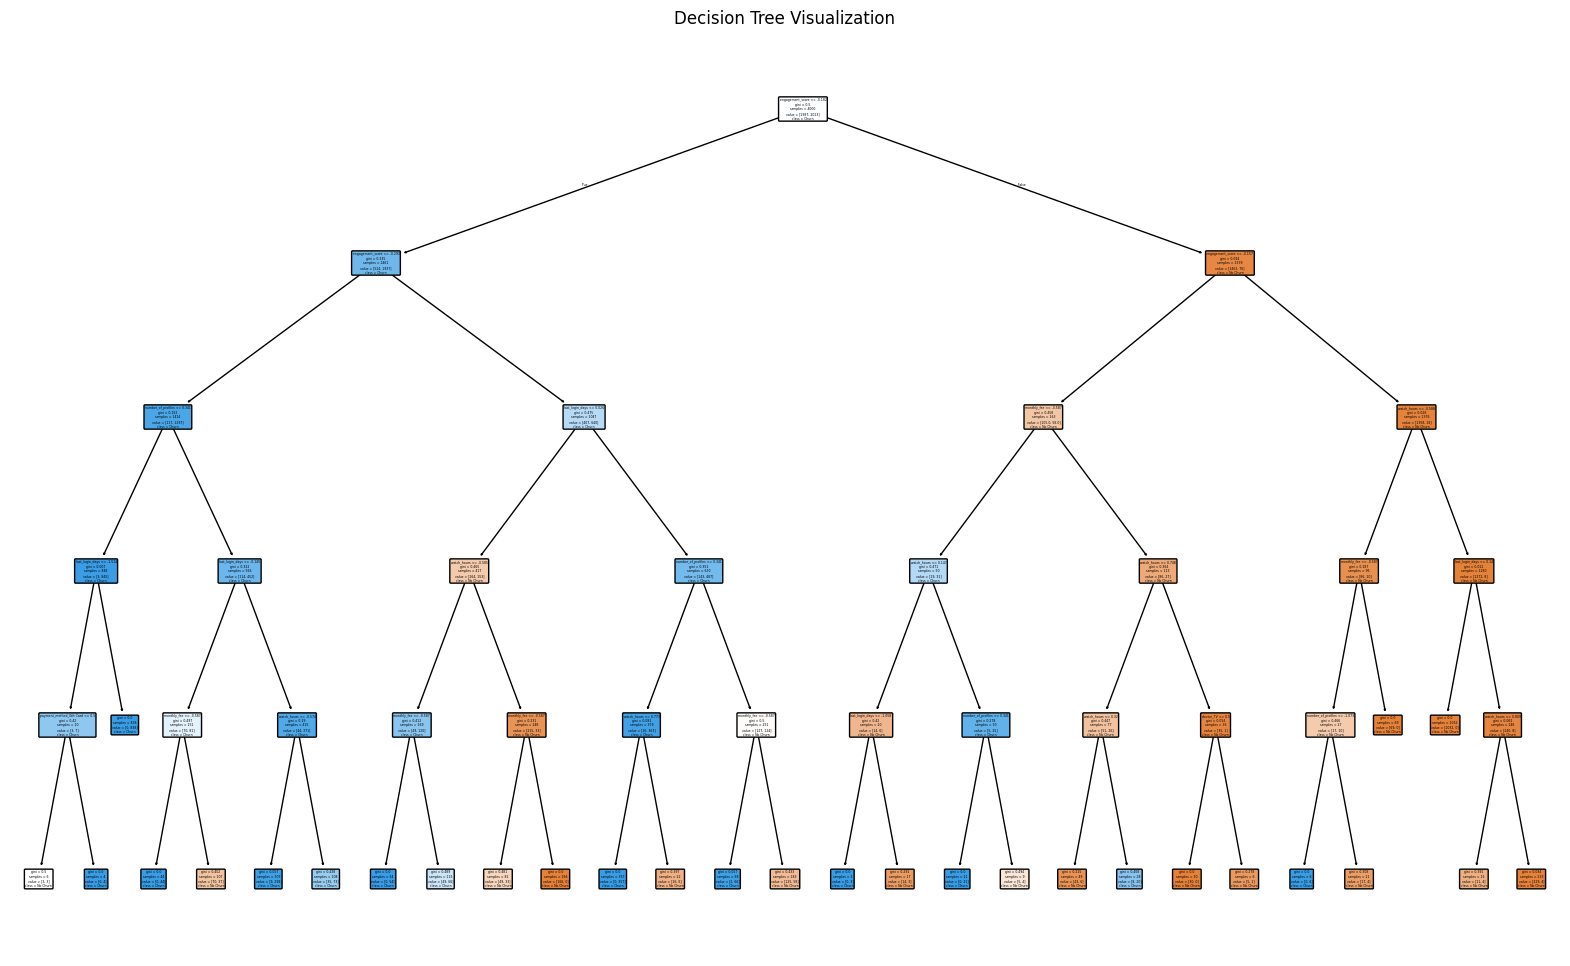

In [24]:
# --- 6. Visualize the Decision Tree ---
print("\nVisualizing the Decision Tree...")
plt.figure(figsize=(20, 12))
plot_tree(dt_classifier, 
          filled=True, 
          rounded=True, 
          class_names=['No Churn', 'Churn'], 
          feature_names=X.columns)
plt.title('Decision Tree Visualization')
plt.savefig('decision_tree.png')
print("Decision Tree plot saved as 'decision_tree.png'")
plt.show()

## Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier


Training Random Forest model...
Model training complete.

Model Accuracy: 0.9810

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       498
           1       0.99      0.97      0.98       502

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


Confusion Matrix:
[[493   5]
 [ 14 488]]

Confusion matrix plot saved as 'confusion_matrix_random_forest.png'


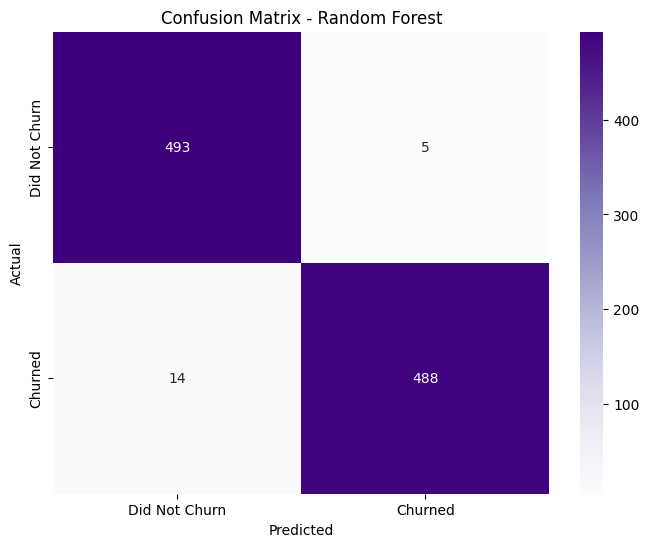

In [26]:
# --- 4. Train Random Forest Model ---
print("\nTraining Random Forest model...")
# n_estimators is the number of trees in the forest. 100 is a good starting point.
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
print("Model training complete.")

In [27]:
# --- 5. Evaluate the Model ---
y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)



Model Accuracy: 0.9810

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       498
           1       0.99      0.97      0.98       502

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


Confusion Matrix:
[[493   5]
 [ 14 488]]



Confusion matrix plot saved as 'confusion_matrix_random_forest.png'


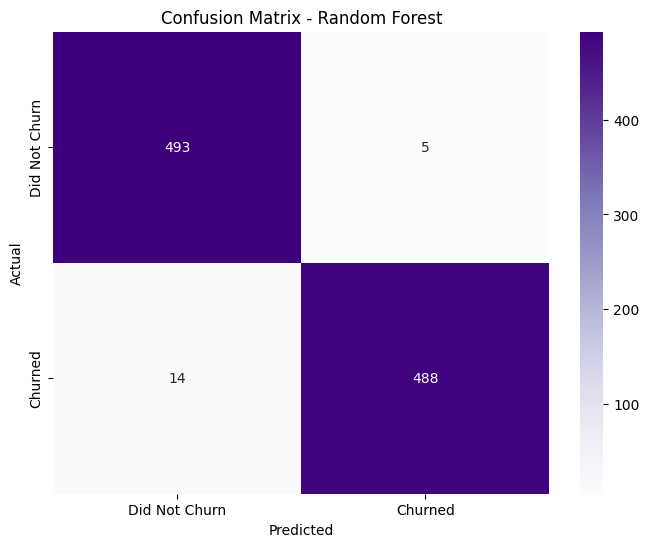

In [28]:
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Did Not Churn', 'Churned'], yticklabels=['Did Not Churn', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.savefig('confusion_matrix_random_forest.png')
print("\nConfusion matrix plot saved as 'confusion_matrix_random_forest.png'")
plt.show()